In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1)  Data Preparation

In [2]:
df = pd.read_excel("heart.xlsx")

In [3]:
df.head()

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [4]:
df = pd.read_excel("heart.xlsx", sheet_name="Heart_disease")

# 2) Exploratory Data Analysis (EDA): 

In [5]:
df['num'].value_counts()

num
0    399
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [8]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [9]:
df.shape

(908, 13)

In [10]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [11]:
df_numeric = df._get_numeric_data()

In [12]:
df_numeric.columns

Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'oldpeak', 'num'], dtype='object')

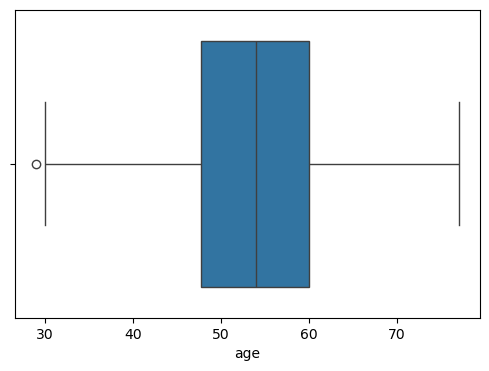

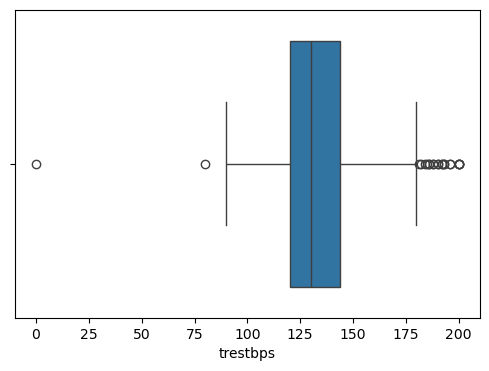

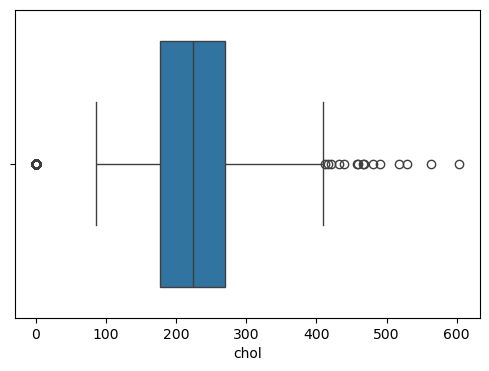

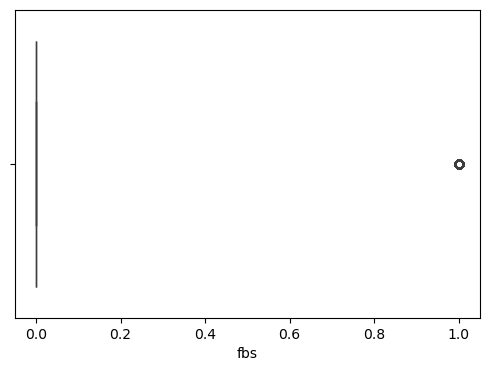

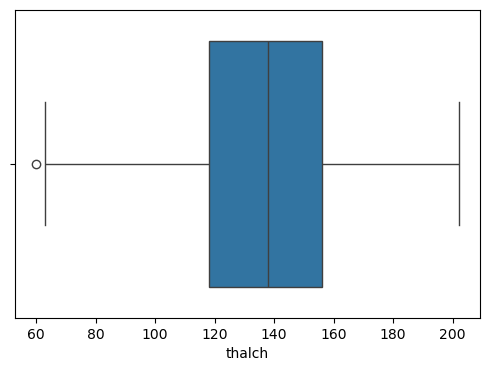

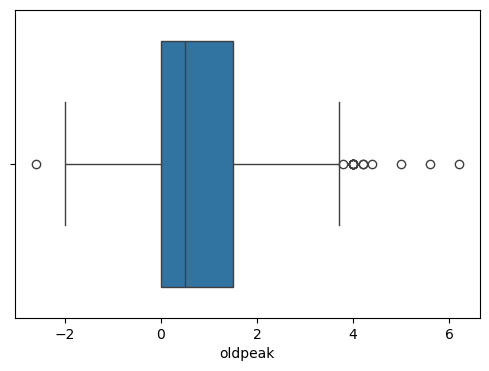

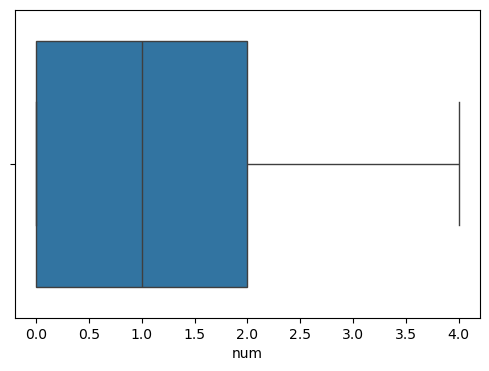

In [13]:
col=['age', 'trestbps', 'chol', 'fbs', 'thalch', 'oldpeak', 'num']
for i in col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_numeric[i])

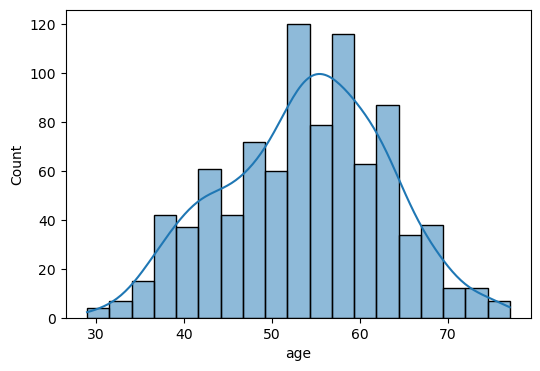

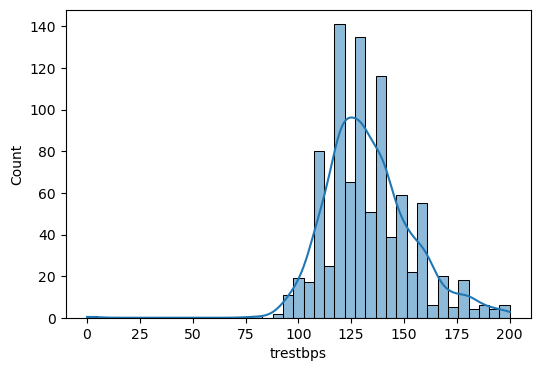

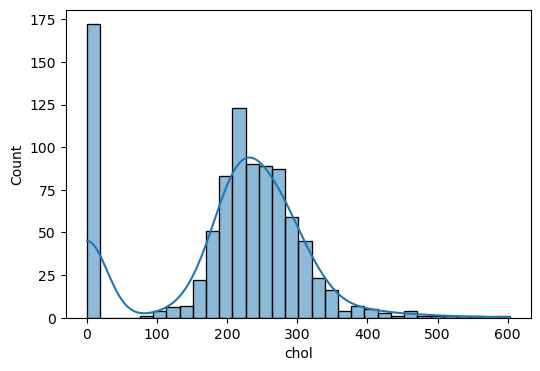

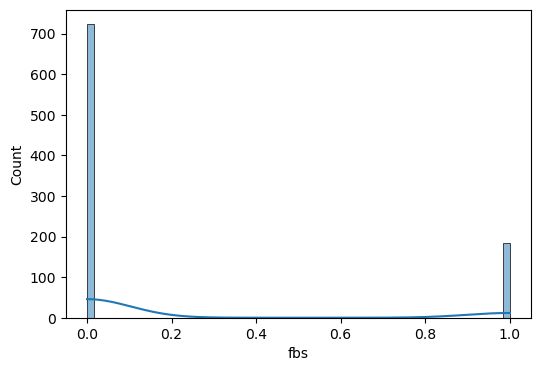

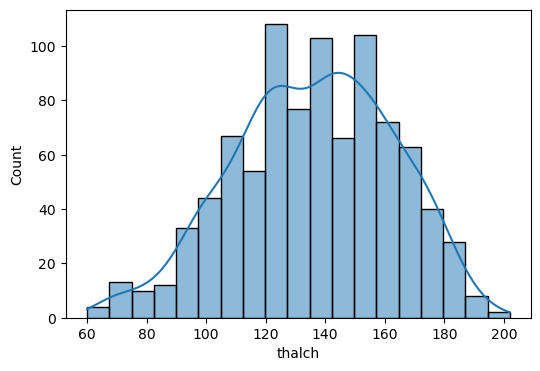

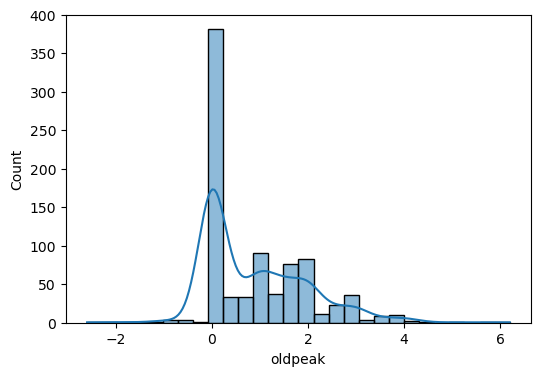

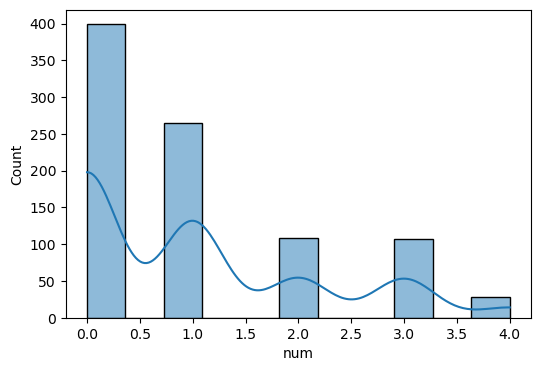

In [14]:
col=['age', 'trestbps', 'chol', 'fbs', 'thalch', 'oldpeak', 'num']
for i in col :
    plt.figure(figsize=(6,4))
    sns.histplot(x=df_numeric[i],kde=True)

<Axes: >

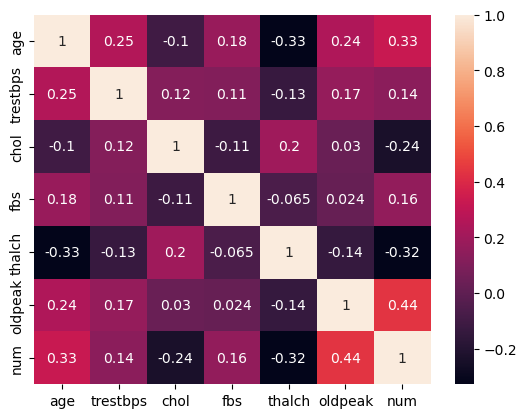

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot= True)

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
label =LabelEncoder()

# 3). Feature Engineering

In [18]:

cols = ['sex', 'cp', 'restecg', 'slope', 'thal']

for col in cols:
    df[col] = label.fit_transform(df[col])

In [19]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,True,0,150,False,2.3,0,0,0
1,41,1,1,135,203,False,1,132,False,0.0,1,0,0
2,57,1,0,140,192,False,1,148,False,0.4,1,0,0
3,52,1,3,118,186,False,0,190,False,0.0,1,0,0
4,57,1,0,110,201,False,1,126,True,1.5,1,0,0


In [20]:
df['exang'] = df['exang'].replace({
    'FALSE': False,
    'TURE': True,   
    'TRUE': True
})

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7984\3588252542.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].replace({


In [21]:
df['exang'] = df['exang'].astype(int)

In [22]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [23]:
me=df['oldpeak'].mean()
print(me)

0.8912529550827422


In [24]:
df['oldpeak'].fillna(me, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7984\627875463.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(me, inplace=True)


In [25]:
x = df.drop('num',axis= 1)
y = df['num']

# 4) Decision Tree Classification: 

In [26]:
from sklearn.model_selection import train_test_split

In [50]:
x_train ,x_test, y_train, y_test = train_test_split(x,y,test_size =0.2, random_state=42)

In [51]:
from sklearn.tree import DecisionTreeClassifier

In [52]:
dtc= DecisionTreeClassifier()

In [53]:
dtc.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
y_pred = dtc.predict(x_test)

In [32]:
y_pred

array([1, 1, 0, 2, 1, 1, 1, 0, 1, 1, 3, 2, 0, 0, 0, 2, 0, 0, 0, 3, 0, 1,
       2, 1, 0, 2, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       2, 2, 1, 0, 0, 1, 0, 3, 0, 1, 0, 0, 3, 1, 1, 0, 0, 0, 3, 0, 0, 2,
       1, 1, 1, 0, 0, 3, 3, 3, 0, 3, 1, 0, 3, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 2, 0, 3, 0, 0, 3, 2, 4, 0, 1, 0, 0, 0, 1, 1, 0, 2, 3, 1, 1, 2,
       0, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       2, 1, 1, 0, 1, 0, 2, 0, 4, 0, 0, 0, 0, 1, 3, 0, 1, 0, 0, 0, 1, 2,
       0, 1, 1, 0, 1, 0, 1, 3, 0, 0, 0, 0, 3, 1, 2, 3, 0, 0, 0, 2, 0, 4,
       1, 1, 4, 2, 0, 0])

In [56]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [58]:
print(accuracy_score(y_test,y_pred))

0.489010989010989


In [57]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.73      0.74        89
           1       0.29      0.31      0.30        48
           2       0.32      0.32      0.32        22
           3       0.11      0.12      0.11        17
           4       0.00      0.00      0.00         6

    accuracy                           0.49       182
   macro avg       0.29      0.30      0.29       182
weighted avg       0.49      0.49      0.49       182



In [59]:
confusion_matrix(y_test,y_pred)

array([[65, 14,  6,  4,  0],
       [16, 15,  8,  9,  0],
       [ 4,  6,  7,  4,  1],
       [ 2, 11,  0,  2,  2],
       [ 0,  5,  1,  0,  0]])

# 5) Hyperparameter Tuning: 

In [38]:
dtc1=DecisionTreeClassifier( criterion='gini',  max_depth=4, min_samples_split=2, random_state=42)

In [39]:
dtc1.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
y_pred1 = dtc1.predict(x_test)

In [43]:
print(accuracy_score(y_test,y_pred1))

0.5769230769230769


In [44]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.73      0.84      0.78        89
           1       0.45      0.48      0.46        48
           2       0.33      0.14      0.19        22
           3       0.21      0.24      0.22        17
           4       0.00      0.00      0.00         6

    accuracy                           0.58       182
   macro avg       0.34      0.34      0.33       182
weighted avg       0.53      0.58      0.55       182



C:\Users\Lenovo\python_practise\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\python_practise\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\python_practise\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### without hyperparameter tuning the accuracy was 53% but after hyperparameter tuning the accuracy increased to 58% . even the tree with tuning has good look.


# 6) Model Evaluation and Analysis: 

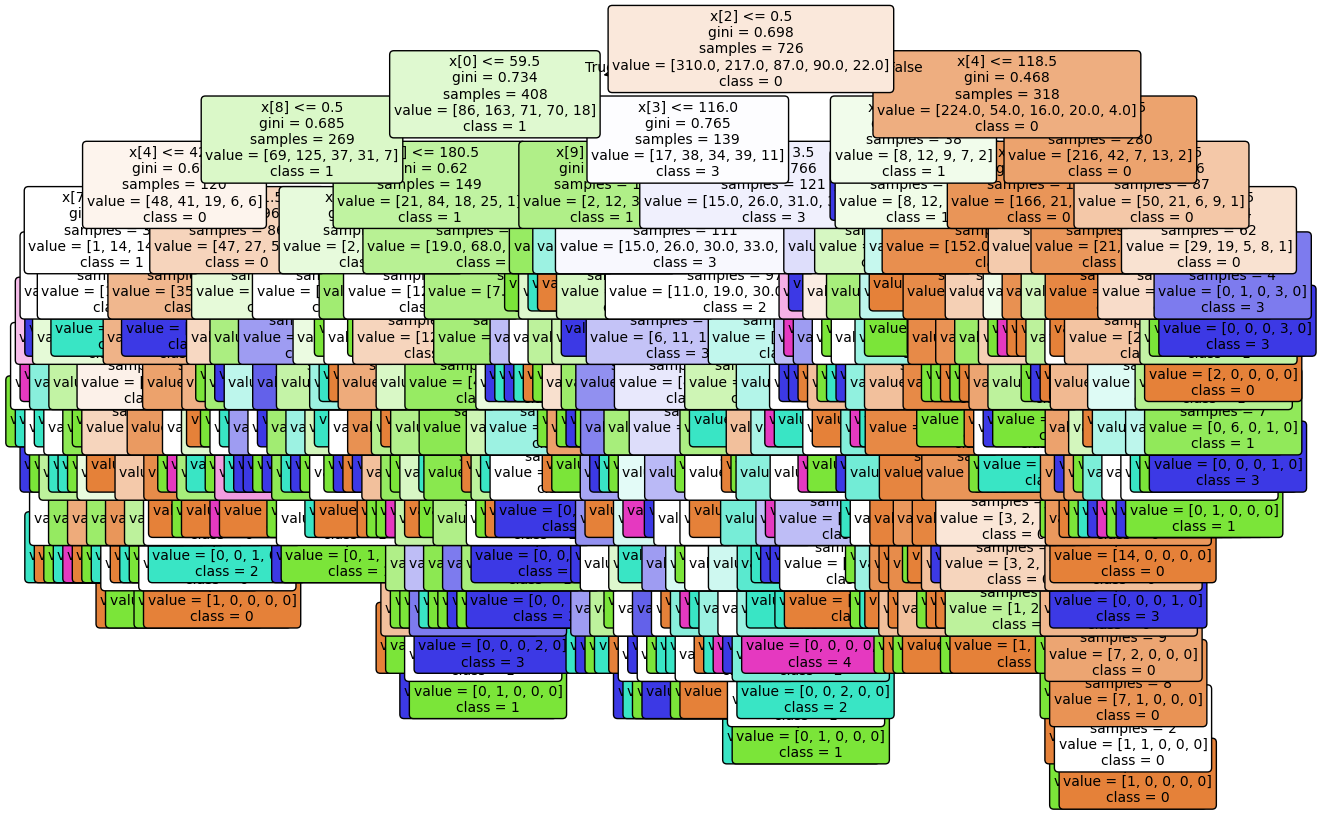

In [65]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dtc.fit(x_train, y_train)


plt.figure(figsize=(15,10))
plot_tree(dtc,
          filled=True,
          class_names=[str(cls) for cls in dtc.classes_],  # This never fails
          rounded=True,
          fontsize=10)   # Added smaller font so text fits
plt.show()

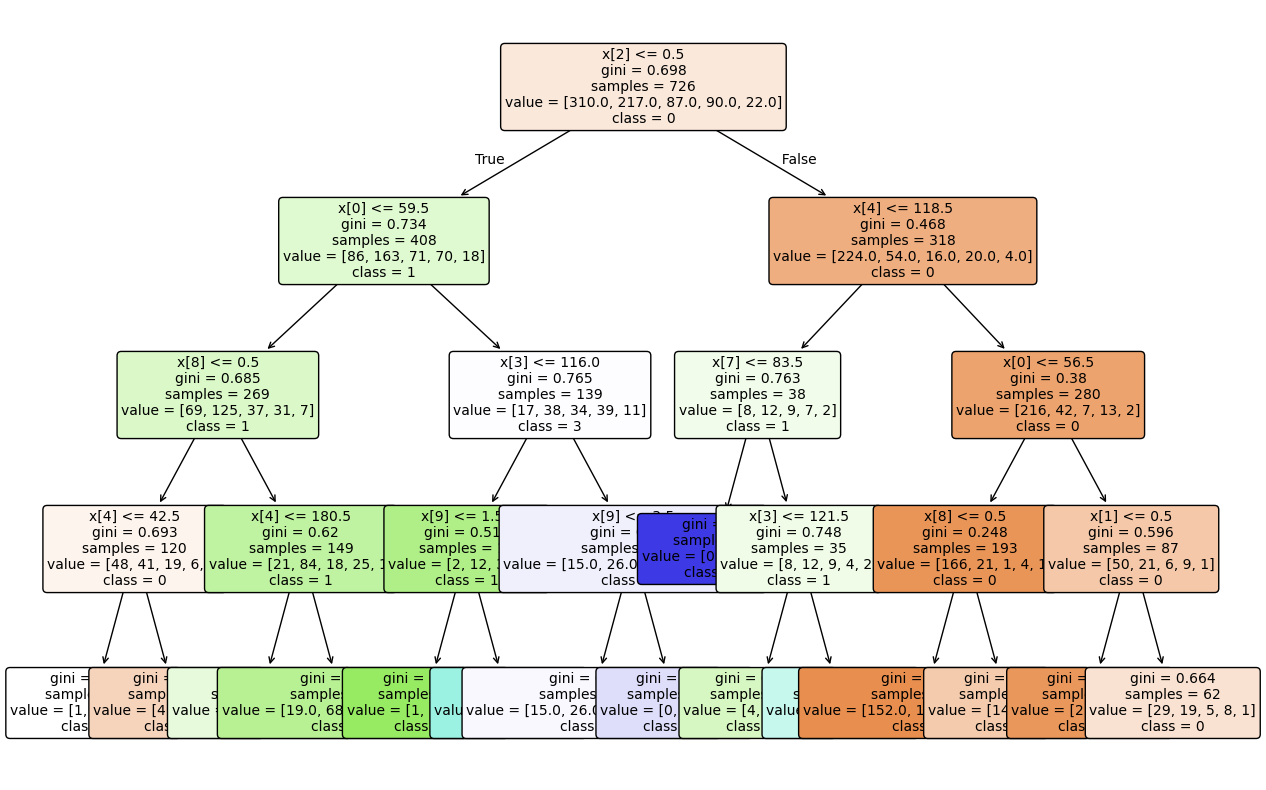

In [66]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Make sure it's fitted (just in case)
dtc1.fit(x_train, y_train)

# Plot with automatic string conversion
plt.figure(figsize=(15,10))
plot_tree(dtc1,
          filled=True,
          class_names=[str(cls) for cls in dtc.classes_],  # This never fails
          rounded=True,
          fontsize=10)   # Added smaller font so text fits
plt.show()

## i did this on my own

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 8],          # How deep the tree goes
    'min_samples_split': [2, 5, 10],        # Min samples to split a node
    'min_samples_leaf': [1, 2, 4],          # Min samples at a leaf node
    'criterion': ['gini', 'entropy']        # Which impurity measure
}

In [47]:
# Create the base model
dtc = DecisionTreeClassifier(random_state=42)

# Set up GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dtc,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross validation
    scoring='accuracy',      # What metric to optimize
    n_jobs=-1,               # Use all CPU cores (faster)
    verbose=1                # Shows progress bar
)

# Fit it on your TRAINING data (X_train, y_train)
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [48]:
# Print the best hyperparameters found
print("Best Parameters:", grid_search.best_params_)

# Print the average CV accuracy (across the 5 folds)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Get the final model trained with these best params
best_model = grid_search.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.530307038261691


# interview question

#### the common hyperparameter are max_depth, citerion, by max depth we can control th edepth o fthe tree and my cetrionn we can  change the gini or entropy they help in improving the accuracy..

####  in label encoding the the labels are assigned as 1,2 etc if the column i s fueltype the diesel is mapped as 1 or petrol as 2 , but one hot encoding the seprate column will be created like fuel_petrol and fuel_diesel and this way the one hot encoding is done.